# ⚙️ Notebook 3 — Pipeline 2: Feature Engineering

**Objetivo:** Crear nuevas variables (features) y preparar los datos para los modelos  
**Input:** `data/02_intermediate/clean_attributes.csv`  
**Output:** `X_train`, `X_test`, `y_train`, `y_test`

---
### ¿Qué es Feature Engineering?
Es el proceso de crear variables nuevas combinando las existentes, para que los modelos
de ML puedan encontrar patrones más fácilmente. En lugar de tener `has_beard`, `patchy_beard`
y `has_mustache` por separado, creamos `score_facial_hair` que resume todo en uno.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings; warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
print('✅ Librerías cargadas')

✅ Librerías cargadas


In [2]:
# Cargar dataset limpio
df = pd.read_csv('../data/02_intermediate/clean_attributes.csv')
print(f'Dataset limpio: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head(3)

Dataset limpio: 13,141 filas × 33 columnas


,attractive,blurry_image,sharp_jawline,high_cheekbones,smiling,bald,receeding_hairline,long_hair,curly_hair,grey_hair,...,big_lips,sharp_nose,adult,old,mouth_open,male,double_chin,veil,wrinkle,chubby
0,0,0,0,1,1,0,0,0,0,0,...,0,0,1,0,0,1,0,0,1,1
1,1,0,0,1,1,0,0,1,0,0,...,0,0,1,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,1,0,0,0,0


## Paso 1 — Crear Features Compuestas

Agrupamos atributos relacionados en scores numéricos (0, 1, 2 o 3):

In [3]:
df_feat = df.copy()

# Score de vello facial (0=sin vello, 3=barba+bigote+parche)
df_feat['score_facial_hair'] = df[['has_beard','patchy_beard','has_mustache']].sum(axis=1)

# Score de cabello
df_feat['score_hair_features'] = df[['long_hair','curly_hair','grey_hair','black_hair']].sum(axis=1)

# Score de piel (positivo=buena piel, negativo=problemas)
df_feat['score_skin'] = df['clear_skin'] - df['oily_skin'] - df['dark_circles']

# Score de envejecimiento
df_feat['score_aging'] = df[['old','wrinkle','double_chin','receeding_hairline']].sum(axis=1)

# Score de características femeninas
df_feat['score_feminine'] = df[['has_makeup','veil','long_hair','big_lips']].sum(axis=1)

print('Nuevas features creadas:')
nuevas = ['score_facial_hair','score_hair_features','score_skin','score_aging','score_feminine']
print(df_feat[nuevas].describe().round(3))

Nuevas features creadas:
       score_facial_hair  score_hair_features  score_skin  score_aging  \
count          13141.000            13141.000   13141.000    13141.000   
mean               0.706                1.057      -0.095        0.608   
std                0.941                0.600       0.840        0.817   
min                0.000                0.000      -2.000        0.000   
25%                0.000                1.000      -1.000        0.000   
50%                0.000                1.000       0.000        0.000   
75%                2.000                1.000       1.000        1.000   
max                3.000                3.000       1.000        4.000   

       score_feminine  
count       13141.000  
mean            0.419  
std             0.745  
min             0.000  
25%             0.000  
50%             0.000  
75%             1.000  
max             4.000  


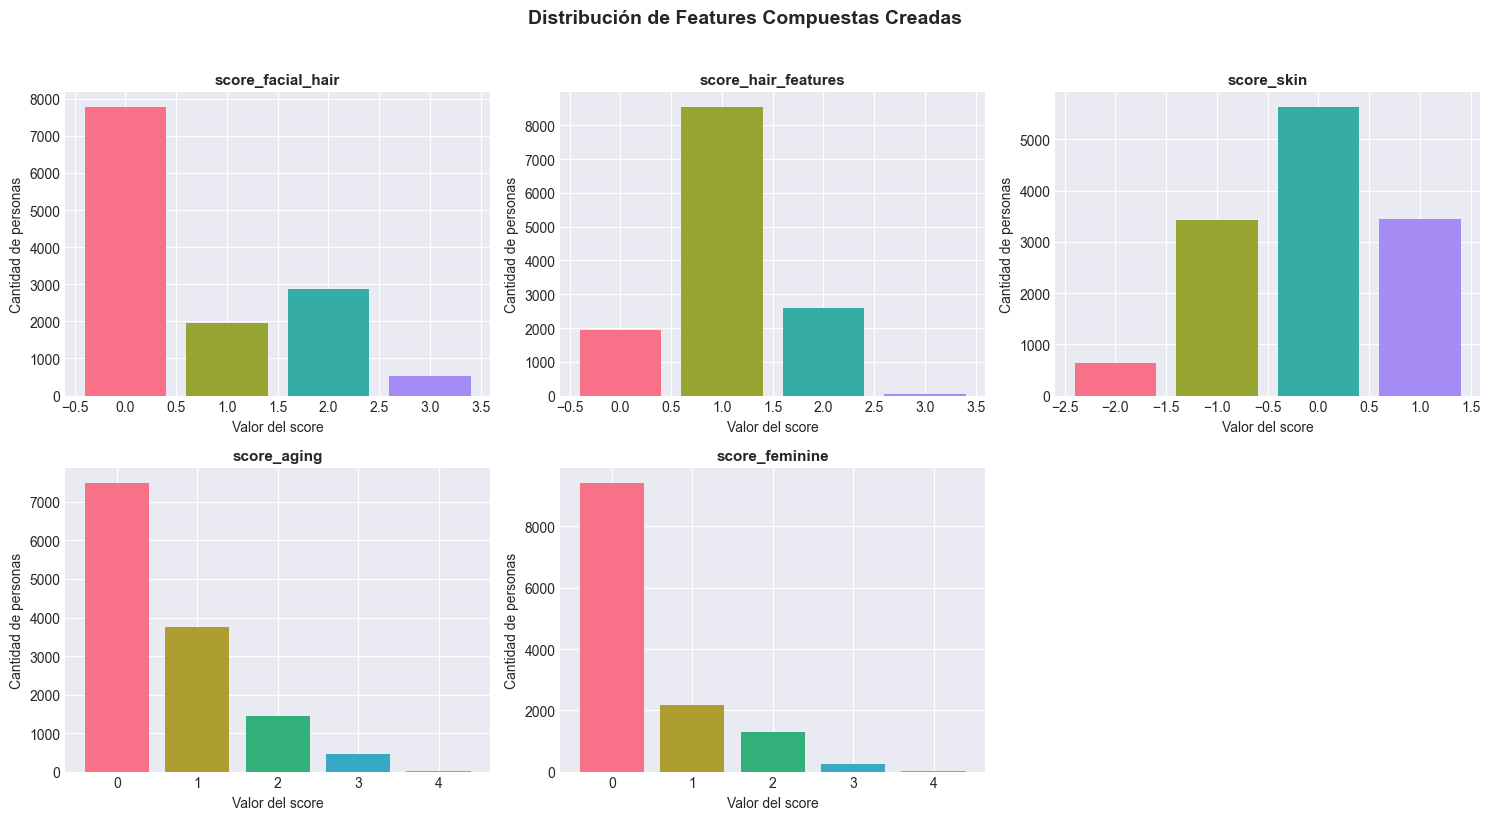

In [4]:
# Visualizar distribución de features nuevas
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(nuevas):
    conteo = df_feat[col].value_counts().sort_index()
    axes[i].bar(conteo.index, conteo.values, color=sns.color_palette('husl', len(conteo)))
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Valor del score')
    axes[i].set_ylabel('Cantidad de personas')

axes[-1].axis('off')  # Ocultar último subgráfico vacío
plt.suptitle('Distribución de Features Compuestas Creadas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/08_reporting/features_compuestas.png', dpi=120, bbox_inches='tight')
plt.show()

## Paso 2 — Selección de Features por Correlación

In [5]:
# Separar target
y = df_feat['attractive']
X = df_feat.drop(columns=['attractive'])

# Calcular correlación con el target
THRESHOLD = 0.05
correlaciones = X.corrwith(y).abs().sort_values(ascending=False)

seleccionadas = correlaciones[correlaciones >= THRESHOLD]
descartadas   = correlaciones[correlaciones < THRESHOLD]

print(f'Features totales:       {len(correlaciones)}')
print(f'Features seleccionadas (corr >= {THRESHOLD}): {len(seleccionadas)}')
print(f'Features descartadas:   {len(descartadas)}')
print(f'\nFeatures descartadas: {descartadas.index.tolist()}')

Features totales:       37
Features seleccionadas (corr >= 0.05): 26
Features descartadas:   11

Features descartadas: ['mouth_open', 'big_lips', 'dark_circles', 'oily_skin', 'adult', 'veil', 'wearing_glasses', 'patchy_beard', 'score_facial_hair', 'high_cheekbones', 'wearing_hat']


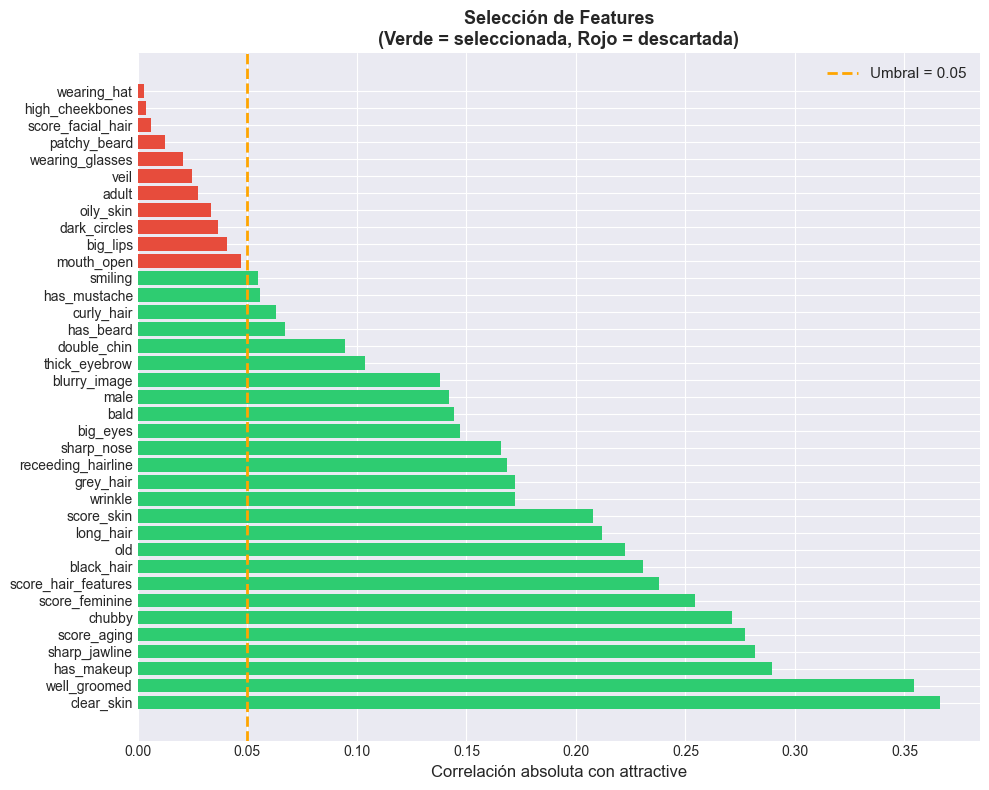

In [6]:
# Visualizar importancia de features
fig, ax = plt.subplots(figsize=(10, 8))
colores = ['#2ECC71' if v >= THRESHOLD else '#E74C3C' for v in correlaciones.values]
ax.barh(correlaciones.index, correlaciones.values, color=colores)
ax.axvline(x=THRESHOLD, color='orange', linewidth=2, linestyle='--', label=f'Umbral = {THRESHOLD}')
ax.set_xlabel('Correlación absoluta con attractive', fontsize=12)
ax.set_title('Selección de Features\n(Verde = seleccionada, Rojo = descartada)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../data/08_reporting/seleccion_features.png', dpi=120, bbox_inches='tight')
plt.show()

## Paso 3 — División Train / Test

=== División Train / Test ===
X_train: 10,512 filas × 26 features
X_test:  2,629 filas × 26 features

Balance en train: 30.7% positivos
Balance en test:  30.7% positivos

✅ Stratify=True garantiza el mismo balance en ambos conjuntos


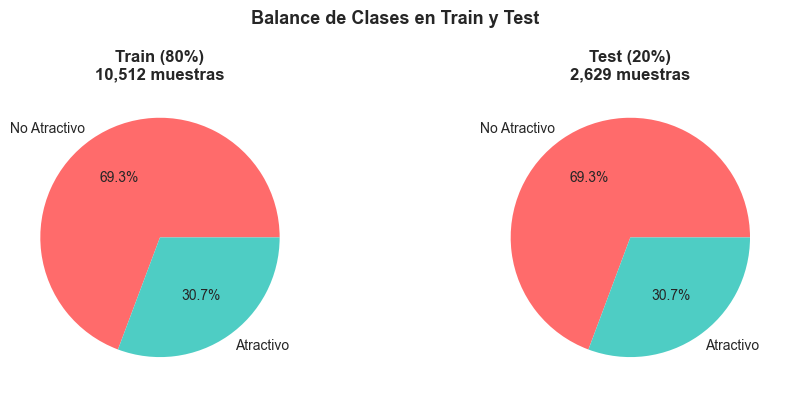

In [7]:
X_sel = X[seleccionadas.index]
X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.2, random_state=42, stratify=y
)

print('=== División Train / Test ===')
print(f'X_train: {X_train.shape[0]:,} filas × {X_train.shape[1]} features')
print(f'X_test:  {X_test.shape[0]:,} filas × {X_test.shape[1]} features')
print(f'\nBalance en train: {y_train.mean()*100:.1f}% positivos')
print(f'Balance en test:  {y_test.mean()*100:.1f}% positivos')
print(f'\n✅ Stratify=True garantiza el mismo balance en ambos conjuntos')

# Gráfico de proporciones
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (nombre, y_part) in zip(axes, [('Train (80%)', y_train), ('Test (20%)', y_test)]):
    conteo = y_part.value_counts()
    ax.pie(conteo.values, labels=['No Atractivo', 'Atractivo'],
           autopct='%1.1f%%', colors=['#FF6B6B','#4ECDC4'])
    ax.set_title(f'{nombre}\n{len(y_part):,} muestras', fontweight='bold')
plt.suptitle('Balance de Clases en Train y Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/08_reporting/split_train_test.png', dpi=120, bbox_inches='tight')
plt.show()

## ✅ Resumen del Pipeline 2

| Paso | Acción | Resultado |
|------|--------|-----------|
| 1 | Crear features compuestas | +5 nuevas variables (scores) |
| 2 | Seleccionar por correlación | De 37 → 26 features útiles |
| 3 | Split train/test | 10.512 train / 2.629 test |

Los datos quedan listos para entrenar los modelos en el Pipeline 3.